In [28]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [51]:
!pip install -U sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 59.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 634.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sentence_transformers import SentenceTransformer, util
from sklearn.preprocessing import LabelEncoder

In [76]:
data = pd.read_csv('/content/gdrive/My Drive/volunteers.csv')
# trim unneeded cols
data = data.dropna()
data = data.drop(columns=['Volunteer Name', 'Age', 'Gender', 'Location'])
data = pd.DataFrame(data)

In [77]:
data.head()
# data.describe()

,Skill A,Skill B,Availability,Type of Organization
0,Animal care,Customer service,Weekends,Pet and Animal Service
1,Healthcare,Communication,Weekdays,Healthcare
2,Youth mentoring,Teaching,Flexible,Youth Development
3,Event planning,Social media,Evenings,Youth Development
4,Data analysis,Fundraising,Weekdays,Healthcare


In [78]:
df = data
# Check for missing values and handle them if necessary
df.dropna(inplace=True)

# Initialize SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Preprocess text columns into embeddings
text_columns = ['Skill A', 'Skill B', 'Availability']
embeddings = []

for col in text_columns:
    embeddings.append(model.encode(df[col].values.tolist()))

# Concatenate embeddings
X = np.concatenate(embeddings, axis=1)

# Target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Type of Organization'].values)

In [80]:
print(X)
print(y_encoded)

[[-0.02828646 -0.00100228  0.10366305 ... -0.05252956 -0.07706106
   0.00609115]
 [-0.03235556  0.08877653 -0.00343595 ...  0.02360271 -0.08579203
   0.01972225]
 [-0.02668384  0.08353774 -0.01426901 ... -0.0275905   0.06301742
   0.00035336]
 ...
 [ 0.02005382  0.00261839 -0.03468569 ... -0.05252956 -0.07706106
   0.00609115]
 [ 0.05343218  0.05578497  0.02380044 ... -0.0275905   0.06301742
   0.00035336]
 [-0.01433577  0.07699509 -0.02578768 ...  0.02360271 -0.08579203
   0.01972225]]
[1 0 2 2 0 1 0 2 1 0 2 1 0 2 1 0 2 0 2 1 0 2 2 1 0 2 1 0 2 1 0 2 1 0 2 0 2
 1 0 2 1 0 2 2 1 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0]


In [83]:
# Linear Regression Model (for fun)

# y = y.values
# X = X.values

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2, random_state=144)

Training Accuracy:  0.9999999999993586
Test Accuracy:  0.22767081795030653
MSE 0.41129956440516224
R2 0.22767081795030653


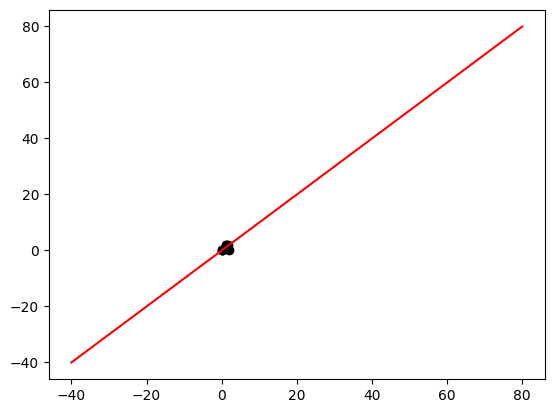

In [84]:
# fit regressor
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# generate predictions
y_predict = regressor.predict(X_test)

# graph comparison of train and test
plt.scatter(y_predict, y_test, color='black')
x = np.linspace(-40, 80)
plt.plot(x, x, color='red')

# get accuracies
print("Training Accuracy: ", regressor.score(X_train, y_train))
print("Test Accuracy: ", regressor.score(X_test, y_test))

# get metrics
print('MSE', mean_squared_error(y_test, y_predict))
print('R2', r2_score(y_test, y_predict))

way overfitting, need to mess around with it more

Training Accuracy:  0.9999999999076579
Test Accuracy:  0.2589014839271532
MSE 0.39466784879619066
R2 0.2589014839271532


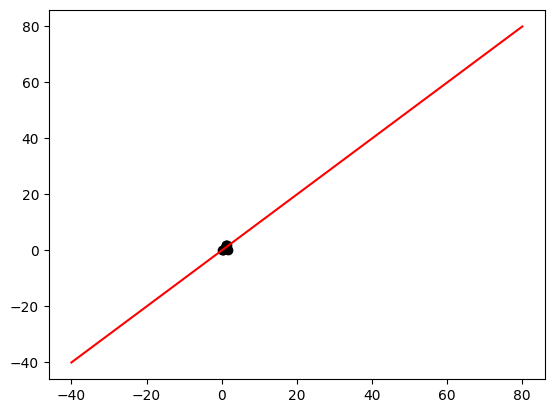

In [85]:
# polynomial regression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

regressor = LinearRegression()
regressor.fit(X_train_poly, y_train)

y_predict_poly = regressor.predict(X_test_poly)

# graph comparison of train and test
plt.scatter(y_predict_poly, y_test, color='black')
x = np.linspace(-40, 80)
plt.plot(x, x, color='red')

# get accuracies
print("Training Accuracy: ", regressor.score(X_train_poly, y_train))
print("Test Accuracy: ", regressor.score(X_test_poly, y_test))

# get metrics
print('MSE', mean_squared_error(y_test, y_predict_poly))
print('R2', r2_score(y_test, y_predict_poly))

also way overfitted, might be the dataset size